<a href="https://colab.research.google.com/github/rongxie2023/dlcv/blob/main/Chapter03/10-Learning_rate_annealing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
import torchvision.transforms as transforms 

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(2025)

In [11]:
data_folder = '../data/FMNIST' # This can be any directory you want to 


transform = transforms.Compose([
    transforms.ToTensor()   #这个函数会将数据归一化
])

def get_data(): 
    train_dataset = datasets.FashionMNIST(root=data_folder, train=True, transform=transform, download=True)
    test_dataset = datasets.FashionMNIST(root=data_folder, train=False, transform=transform, download=True)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)
    return train_loader,test_loader


In [12]:
lr=1e-3

from torch.optim import SGD, Adam
def get_model():
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    # optimizer = SGD(model.parameters(), lr=lr)
    optimizer = Adam(model.parameters(), lr=lr)

    return model, loss_fn, optimizer

def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    return batch_loss.item()

def accuracy(x, y, model):
    model.eval()
    # this is the same as @torch.no_grad 
    # at the top of function, only difference
    # being, grad is not computed in the with scope
    with torch.no_grad():
        prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

In [13]:
@torch.no_grad()
def val_loss(x, y, model):
    prediction = model(x)
    val_loss = loss_fn(prediction, y)
    return val_loss.item()

In [14]:
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

In [15]:
from torch import optim
# 根据监控的度量（如验证损失）来动态调整学习率。
# 当监控的度量在设定的耐心期（patience）内没有显著改善时，学习率会按照设定的因子（factor）降低。
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=0, threshold = 0.001, min_lr = 1e-5, threshold_mode = 'abs')
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
# StepLR，每5个epoch将学习率乘以0.1
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []
num_epochs=30

# 记录上一次的学习率，初始值可以设为 None 或者你期望的任何初始值
last_lr = None
for epoch in range(num_epochs):
    print(epoch)
    train_epoch_losses, train_epoch_accuracies = [], []
    for x,y in trn_dl:
        x=x.to(device)
        y=y.to(device)
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss) 
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_loss = np.array(train_epoch_losses).mean()
    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for x,y in val_dl:
        x=x.to(device)
        y=y.to(device)
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)

    val_epoch_accuracy = np.mean(val_is_correct)
    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)

    # 获取当前的学习率
    current_lr = scheduler.get_last_lr()[0]
    
    # 检查学习率是否发生变化
    if last_lr != current_lr:
        print(f"Epoch {epoch + 1}: Learning rate changed to {current_lr}")
        last_lr = current_lr  # 更新上一次的学习率为当前的学习率
    scheduler.step(val_epoch_accuracy) 
    # scheduler.step()   


0
Epoch 1: Learning rate changed to 0.001
1
2
Epoch 3: Learning rate changed to 0.0005
3
Epoch 4: Learning rate changed to 0.00025
4
Epoch 5: Learning rate changed to 0.000125
5
6
Epoch 7: Learning rate changed to 6.25e-05
7
Epoch 8: Learning rate changed to 3.125e-05
8
Epoch 9: Learning rate changed to 1.5625e-05
9
Epoch 10: Learning rate changed to 1e-05
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


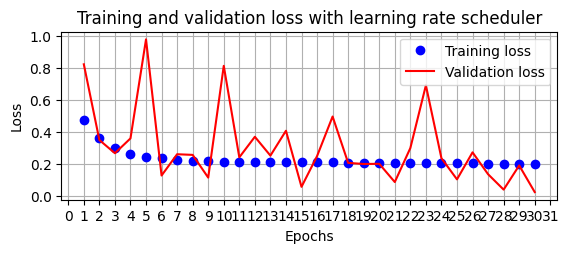

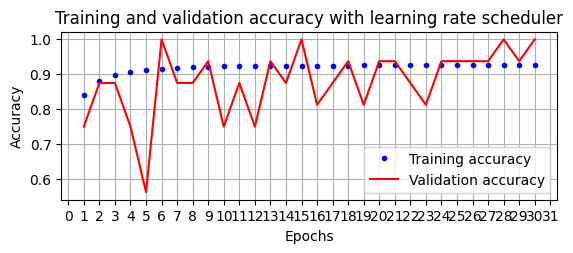

In [16]:
epochs = np.arange(num_epochs)+1
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline
plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title(f'Training and validation loss with learning rate scheduler')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid('off')
plt.show()
plt.subplot(212)
plt.plot(epochs, train_accuracies, 'b.', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title(f'Training and validation accuracy with learning rate scheduler')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
# plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()]) 
plt.legend()
plt.grid('off')
plt.show()